# Evaluation harness and baselines

Before any model is trained, we need three things: a **fair way to test it**, **the bars it has to clear**, and **a sense of how much noise is in any score**. This notebook sets all three up on the real data, using the code in `src/oa_market_intelligence/modeling/` (tested separately; see `docs/evaluation_protocol.md`).

**The question this notebook answers:** if a model has to predict next month's Up / Down / Flat for Zilretta's visit share, how well do simple guesses do, how much of that is just luck, and how precisely can 35 months tell us?

Plain-language terms used below:

- **Walk-forward test:** train on the months up to *t*, predict month *t*, then add month *t* to the training data and repeat. The model never sees the future, exactly as in real monthly use.
- **Always-majority:** always guess the most common label (Flat).
- **Persistence:** guess that next month's direction repeats last month's. The proposal's required bar.
- **Seasonal rule:** for each calendar month, guess the label that month most often had in earlier years. The strongest *simple* baseline, because it uses only the calendar.
- **Random by class mix:** guess at random, in the proportions seen in training. This is what chance looks like.
- **Recall on Down:** of the months that really were Down, how many did we catch? The project's priority metric (PROPOSAL §17.2), because a falling share is what the brand manager most needs to know about.
- **Confidence interval (bootstrap):** a range of plausible values for a score, found by re-drawing the 35 test months with replacement many times. A wide range means the score is not precise.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

from oa_market_intelligence.features.monthly import (
    compute_monthly_features, load_monthly_gold, model_ready_monthly)
from oa_market_intelligence.modeling.baselines import (
    MajorityClassBaseline, PersistenceBaseline, SeasonalBaseline, StratifiedRandomBaseline)
from oa_market_intelligence.modeling.evaluation import (
    CLASSES, DEFAULT_MIN_TRAIN, bootstrap_difference, bootstrap_scores, compare_models,
    confusion, mcnemar_exact, score_table, simulate_scores)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

engine = create_engine("sqlite:///../data/processed/warehouse.db")
gold = load_monthly_gold(engine)
features = compute_monthly_features(gold)
ready = model_ready_monthly(features)

BASELINES = {"always-majority": MajorityClassBaseline, "persistence": PersistenceBaseline,
             "seasonal": SeasonalBaseline}
print(f"{len(gold)} months in Gold; {len(ready)} are model-ready "
      f"({ready.index[0]} to {ready.index[-1]}); {ready.shape[1] - 1} features")

72 months in Gold; 59 are model-ready (202009 to 202507); 22 features


## 1. How the test is laid out

Only **59 of the 72 months** can be used. The first 13 have no label yet, because the label needs 12 months of past volatility plus one difference. Of those 59, the first **24** are used only for initial training (two full seasonal cycles, PROPOSAL §18.3). That leaves **35 months** to be predicted one at a time.

The proposal assumed about 48 test months. With 13 months consumed by the label's warm-up, 35 is the real number. That matters for how much we can conclude, as sections 5 and 6 show.

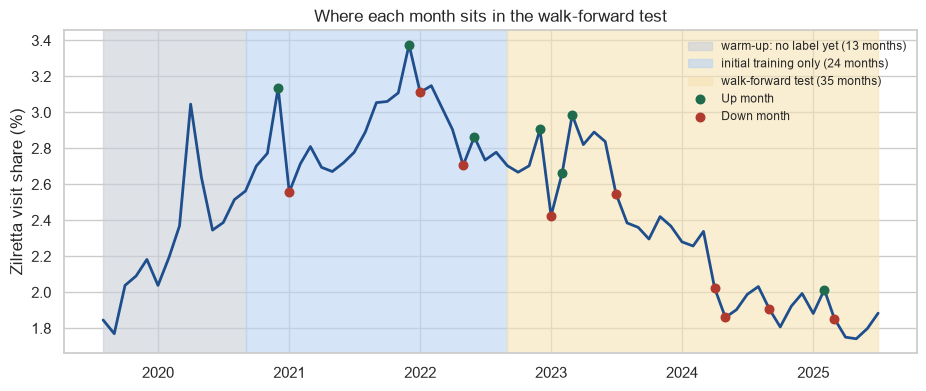

In [2]:
dates = pd.to_datetime(gold["month_id"].astype(str), format="%Y%m")
share = gold["visit_share"] * 100
first_ready = dates[gold["month_id"] == ready.index[0]].iloc[0]
first_test = dates[gold["month_id"] == ready.index[DEFAULT_MIN_TRAIN]].iloc[0]

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(dates, share, color="#1F4E8C", lw=2)
ax.axvspan(dates.iloc[0], first_ready, color="#C9CFD8", alpha=0.6, label="warm-up: no label yet (13 months)")
ax.axvspan(first_ready, first_test, color="#BBD3F2", alpha=0.6, label="initial training only (24 months)")
ax.axvspan(first_test, dates.iloc[-1], color="#F6E3B4", alpha=0.6, label="walk-forward test (35 months)")
labels = features["direction_label"].reindex(gold["month_id"].values).to_numpy()
for cls, color in [("Up", "#1F6B4D"), ("Down", "#B03A2E")]:
    mask = labels == cls
    ax.scatter(dates[mask], share[mask], color=color, s=38, zorder=3, label=f"{cls} month")
ax.set_ylabel("Zilretta visit share (%)")
ax.set_title("Where each month sits in the walk-forward test")
ax.legend(loc="upper right", fontsize=8.5, frameon=False)
plt.show()

## 2. What a model is up against

In the 35 test months most months are Flat. A model that is lazy and always says Flat will look decent on plain accuracy while being useless to the brand manager.

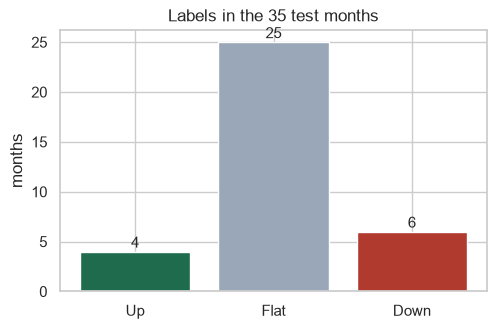

Always saying Flat is right 71.4% of the time, and catches 6 Down months: none of them.


In [3]:
predictions = compare_models(ready, BASELINES, min_train=DEFAULT_MIN_TRAIN)
truth = predictions["y_true"].value_counts().reindex(CLASSES)

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.bar(truth.index, truth.values, color=["#1F6B4D", "#9AA7B8", "#B03A2E"])
for x, v in enumerate(truth.values):
    ax.text(x, v + 0.4, str(v), ha="center", fontsize=11)
ax.set_title(f"Labels in the {len(predictions)} test months")
ax.set_ylabel("months")
plt.show()
print(f"Always saying Flat is right {truth['Flat'] / truth.sum():.1%} of the time, "
      f"and catches {int(truth['Down'])} Down months: none of them.")

## 3. Three baselines, scored

Reading the table: `accuracy` is the share of months called correctly. `balanced_accuracy` averages recall across the classes that occur, so a lazy model can't hide. `recall_down` is the priority metric. `precision_down` is how often a Down call was right.

In [4]:
cols = ["n", "accuracy", "balanced_accuracy", "macro_f1", "precision_down", "recall_down", "recall_up"]
scores = score_table(predictions)[cols]
scores["n"] = scores["n"].astype(int)
scores.round(3)

,n,accuracy,balanced_accuracy,macro_f1,precision_down,recall_down,recall_up
always-majority,35,0.714,0.333,0.278,0.000,0.000,0.00
persistence,35,0.629,0.406,0.406,0.167,0.167,0.25
seasonal,35,0.657,0.419,0.429,0.333,0.167,0.25


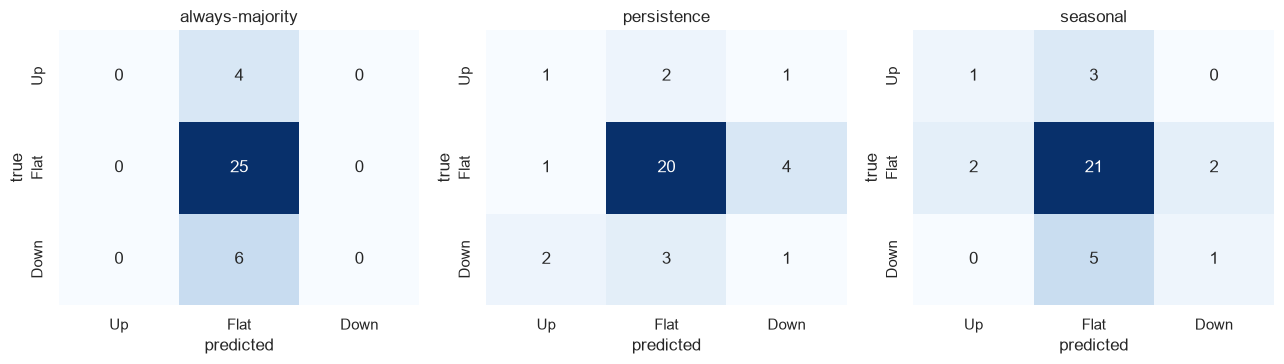

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, name in zip(axes, BASELINES):
    sns.heatmap(confusion(predictions["y_true"], predictions[name]), annot=True, fmt="d", cbar=False,
                cmap="Blues", ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

**Reading the results.**

- **Always-majority** has the best plain accuracy and the worst on everything that matters: it never calls an Up or a Down.
- **Persistence** catches 1 of the 6 Down months. The label measures a *surprise* relative to recent volatility, and a surprise rarely repeats the following month, so "same as last month" is a weak guess for direction, even though it is a strong guess for the share *level*.
- **The seasonal rule** is the strongest simple idea, since December and January were the clearest pattern in the EDA. Out of sample it does only slightly better: 1 of its 3 Down calls was right and it catches 1 of 6 Down months. With just two to four examples of each calendar month in the early training windows, the calendar pattern is thin.

None of the three is impressive. The next sections ask how much of even that is luck.

## 4. What chance looks like

A random guess in the training class mix is the honest yardstick for "is this better than luck". One random run is noisy, so we repeat it 1,000 times and look at the spread.

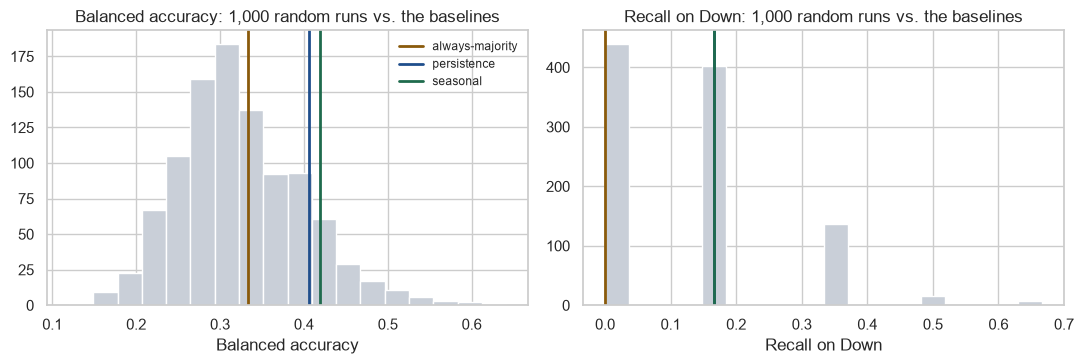

,accuracy,balanced_accuracy,macro_f1,precision_down,recall_down,recall_up
mean,0.550,0.325,0.318,0.151,0.124,0.13
5th pct,0.429,0.213,0.218,0.000,0.000,0.00
95th pct,0.657,0.461,0.444,0.500,0.333,0.50


In [6]:
sim = simulate_scores(ready, lambda seed: (lambda: StratifiedRandomBaseline(seed)),
                      seeds=range(1000), min_train=DEFAULT_MIN_TRAIN)
metrics = ["accuracy", "balanced_accuracy", "macro_f1", "precision_down", "recall_down", "recall_up"]
chance = pd.DataFrame({"mean": sim[metrics].mean(), "5th pct": sim[metrics].quantile(0.05),
                       "95th pct": sim[metrics].quantile(0.95)}).T
base_scores = score_table(predictions)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, metric, title in [(axes[0], "balanced_accuracy", "Balanced accuracy"),
                          (axes[1], "recall_down", "Recall on Down")]:
    ax.hist(sim[metric], bins=18, color="#C9CFD8", edgecolor="white")
    for name, color in [("always-majority", "#8A5A0B"), ("persistence", "#1F4E8C"), ("seasonal", "#1F6B4D")]:
        ax.axvline(base_scores.loc[name, metric], color=color, lw=2, label=name)
    ax.set_title(f"{title}: 1,000 random runs vs. the baselines")
    ax.set_xlabel(title)
axes[0].legend(fontsize=8.5, frameon=False)
plt.tight_layout()
plt.show()
chance[metrics].round(3)

**Reading the chance distribution.** Random guessing in the class mix averages about 0.33 balanced accuracy and about 12% recall on Down, and a lucky run reaches roughly 0.46 balanced accuracy and 33% recall on Down.

Persistence (0.41, 1 of 6) and the seasonal rule (0.42, 1 of 6) both sit **inside the range that pure luck produces**. So at this sample size, none of the baselines can be told apart from guessing. That is a finding, not a failure: it says the direction label is hard to predict from the past alone.

**A practical yardstick for the models:** to claim more than luck, a model's balanced accuracy should be above about **0.46** and its recall on Down above about **33%** (the 95th percentile of chance).

## 5. Does the result depend on where the test starts?

The 24-month starting window is the proposal's choice. Here is the comparison with a shorter (18) and longer (30) starting window.

In [7]:
rows = []
for min_train in (18, 24, 30):
    pred = compare_models(ready, BASELINES, min_train=min_train)
    s = score_table(pred)
    counts = pred["y_true"].value_counts().reindex(CLASSES).fillna(0).astype(int)
    for name in BASELINES:
        rows.append({"start window": min_train, "test months": len(pred), "Down months": counts["Down"],
                     "baseline": name, "accuracy": s.loc[name, "accuracy"],
                     "recall_down": s.loc[name, "recall_down"], "recall_up": s.loc[name, "recall_up"]})
pd.DataFrame(rows).round(3).set_index(["start window", "test months", "Down months", "baseline"])

accuracy  recall_down  recall_up
start window test months Down months baseline                                         
18           41          7           always-majority     0.707        0.000       0.00
                                     persistence         0.610        0.143       0.20
                                     seasonal            0.659        0.143       0.20
24           35          6           always-majority     0.714        0.000       0.00
                                     persistence         0.629        0.167       0.25
                                     seasonal            0.657        0.167       0.25
30           29          5           always-majority     0.759        0.000       0.00
                                     persistence         0.655        0.200       0.50
                                     seasonal            0.621        0.000       0.00

The picture is the same at every start: always-Flat never catches a Down month, and persistence and the seasonal rule catch Down months at roughly chance rates. The conclusion does not hinge on the 24-month choice.

## 6. How precise are these scores? Confidence intervals

Each score comes from only 35 months, and recall on Down from only 6. A **bootstrap** re-draws the 35 months with replacement thousands of times and recomputes the score each time. The middle 95% of those values is the interval. Where a resample happens to contain no Down month, recall on Down is undefined, so that resample is left out instead of being counted as zero.

In [8]:
show = ["accuracy", "balanced_accuracy", "macro_f1", "recall_down", "recall_up"]
tables = {name: bootstrap_scores(predictions["y_true"], predictions[name], n_boot=2000, seed=0)
          for name in BASELINES}
ci = pd.concat({name: t.loc[show, ["point", "lo", "hi"]] for name, t in tables.items()}, names=["baseline", "metric"])
ci.round(3)

point     lo     hi
baseline        metric                                
always-majority accuracy           0.714  0.571  0.857
                balanced_accuracy  0.333  0.333  0.333
                macro_f1           0.278  0.242  0.308
                recall_down        0.000  0.000  0.000
                recall_up          0.000  0.000  0.000
persistence     accuracy           0.629  0.457  0.800
                balanced_accuracy  0.406  0.247  0.636
                macro_f1           0.406  0.252  0.595
                recall_down        0.167  0.000  0.500
                recall_up          0.250  0.000  1.000
seasonal        accuracy           0.657  0.486  0.800
                balanced_accuracy  0.419  0.258  0.659
                macro_f1           0.429  0.242  0.624
                recall_down        0.167  0.000  0.600
                recall_up          0.250  0.000  1.000

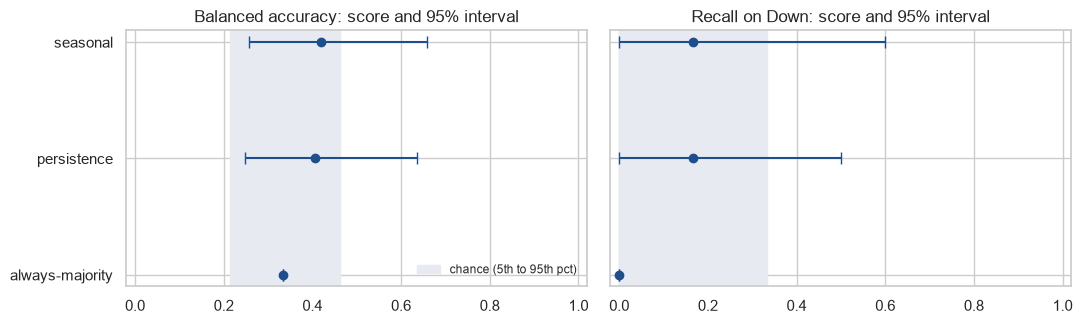

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
names = list(BASELINES)
for ax, metric, title in [(axes[0], "balanced_accuracy", "Balanced accuracy"), (axes[1], "recall_down", "Recall on Down")]:
    ax.axvspan(chance.loc["5th pct", metric], chance.loc["95th pct", metric], color="#E7EAF0", label="chance (5th to 95th pct)")
    for y, name in enumerate(names):
        row = tables[name].loc[metric]
        ax.errorbar(row["point"], y, xerr=[[row["point"] - row["lo"]], [row["hi"] - row["point"]]],
                    fmt="o", color="#1F4E8C", capsize=4)
    ax.set_yticks(range(len(names)), names)
    ax.set_title(f"{title}: score and 95% interval")
    ax.set_xlim(-0.02, 1.02)
axes[0].legend(fontsize=8.5, frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

In [10]:
blocked = {name: bootstrap_scores(predictions["y_true"], predictions[name], n_boot=2000, seed=0, block_length=4)
           for name in BASELINES}
pd.DataFrame({"iid interval": {n: f"[{tables[n].loc['balanced_accuracy', 'lo']:.2f}, {tables[n].loc['balanced_accuracy', 'hi']:.2f}]" for n in BASELINES},
              "4-month-block interval": {n: f"[{blocked[n].loc['balanced_accuracy', 'lo']:.2f}, {blocked[n].loc['balanced_accuracy', 'hi']:.2f}]" for n in BASELINES}}
             ).rename_axis("balanced accuracy, 95%")

,iid interval,4-month-block interval
"balanced accuracy, 95%",,
always-majority,"[0.33, 0.33]","[0.33, 0.33]"
persistence,"[0.25, 0.64]","[0.26, 0.56]"
seasonal,"[0.26, 0.66]","[0.23, 0.65]"


**Reading the intervals.** They are wide. Persistence's recall on Down is 1 of 6, but its interval runs from 0 to about 0.5. Its balanced accuracy of 0.41 has an interval from roughly 0.25 to 0.64. Resampling in 4-month blocks (to respect any month-to-month dependence) gives similar widths. A score from 35 months, with 6 Down months, is a rough estimate.

## 7. Can a baseline be told apart from another? Paired differences and McNemar

The right way to compare two models is on the *same* months. The paired bootstrap re-draws months once and scores both models on them, so luck in which months were drawn cancels out.

In [11]:
pairs = [("persistence", "always-majority"), ("seasonal", "persistence"), ("seasonal", "always-majority")]
rows = []
for a, b in pairs:
    for metric in ("balanced_accuracy", "recall_down", "accuracy"):
        d = bootstrap_difference(predictions["y_true"], predictions[a], predictions[b],
                                 metric=metric, n_boot=2000, seed=0)
        rows.append({"A minus B": f"{a} - {b}", "metric": metric, "difference": d["point"],
                     "95% low": d["lo"], "95% high": d["hi"], "share A beats B": d["share_positive"]})
pd.DataFrame(rows).round(3).set_index(["A minus B", "metric"])

difference  95% low  95% high  share A beats B
A minus B                     metric                                                           
persistence - always-majority balanced_accuracy       0.072   -0.090     0.292            0.731
                              recall_down             0.167    0.000     0.500            0.642
                              accuracy               -0.086   -0.229     0.057            0.096
seasonal - persistence        balanced_accuracy       0.013   -0.313     0.350            0.514
                              recall_down             0.000   -0.500     0.500            0.352
                              accuracy                0.029   -0.171     0.229            0.542
seasonal - always-majority    balanced_accuracy       0.086   -0.080     0.325            0.785
                              recall_down             0.167    0.000     0.600            0.645
                              accuracy               -0.057   -0.200     0.057            0.141

Every interval includes zero: with 35 months, **no baseline reliably beats another**. Plain accuracy even leans the other way, because always-Flat wins it.

McNemar's test (PROPOSAL §18.4) gives the same message from a different angle. It looks only at the months where exactly one model is right. The table shows the p-value for each possible split.

In [12]:
grid = pd.DataFrame(
    {b: {a: mcnemar_exact(["Flat"] * (a + b), (["Flat"] * a) + (["Up"] * b), (["Up"] * a) + (["Flat"] * b))["p_value"]
         for a in range(0, 11)} for b in range(0, 6)})
grid.index.name = "months only model A is right"
grid.columns.name = "months only model B is right"
grid.round(3).style.background_gradient(cmap="Greens_r", vmin=0, vmax=0.2).format("{:.3f}")

months only model B is right,0,1,2,3,4,5
months only model A is right,,,,,,
0,1.000,1.000,0.500,0.250,0.125,0.062
1,1.000,1.000,1.000,0.625,0.375,0.219
2,0.500,1.000,1.000,1.000,0.688,0.453
3,0.250,0.625,1.000,1.000,1.000,0.727
4,0.125,0.375,0.688,1.000,1.000,1.000
5,0.062,0.219,0.453,0.727,1.000,1.000
6,0.031,0.125,0.289,0.508,0.754,1.000
7,0.016,0.070,0.180,0.344,0.549,0.774
8,0.008,0.039,0.109,0.227,0.388,0.581


In [13]:
for label, cls in [("3-class correctness", None), ("Down vs. rest (priority class)", "Down")]:
    r = mcnemar_exact(predictions["y_true"], predictions["always-majority"], predictions["persistence"],
                      positive_class=cls)
    print(f"majority vs persistence, {label}: only-majority-right={r['a_only_correct']}, "
          f"only-persistence-right={r['b_only_correct']}, p={r['p_value']:.3f}")

majority vs persistence, 3-class correctness: only-majority-right=5, only-persistence-right=2, p=0.453
majority vs persistence, Down vs. rest (priority class): only-majority-right=5, only-persistence-right=1, p=0.219


**What this means.** With only 6 Down months in the test window, a model has to be right on at least 6 months where the baseline is wrong, and almost never wrong where the baseline is right, to reach p < 0.05 (the green cells above, such as 6 versus 0). A modest real improvement can easily look "not significant" here.

So the plan for the models is:

1. Report the **size of the improvement** with its **confidence interval** (balanced accuracy, recall on Down, macro-F1), next to the p-value, never the p-value alone.
2. Compare against the **chance band** (balanced accuracy above about 0.46, recall on Down above about 33%), not only against persistence.
3. Treat "no significant difference" as a legitimate, expected finding, as the proposal anticipated (§18.4).
4. Prefer simple, regularized models, because 59 months cannot support complex ones.

## Takeaways

| (35 test months: 25 Flat, 6 Down, 4 Up) | Always-majority | Persistence | Seasonal | Random (mean of 1,000) |
|---|---|---|---|---|
| Accuracy | 71.4% | 62.9% | 65.7% | 55.0% |
| Balanced accuracy | 0.333 | 0.406 | 0.419 | 0.325 |
| Recall on Down | 0 of 6 | 1 of 6 | 1 of 6 | about 12% |

- **No baseline beats chance with confidence.** Persistence and the seasonal rule sit inside the range random guessing produces, and every paired difference between baselines has an interval that includes zero.
- A trained model should be judged against the **chance band** (balanced accuracy above about 0.46, recall on Down above about 33%) and reported with a **confidence interval**.
- Plain accuracy is the wrong yardstick here: the lazy model wins it.
- The harness itself is guarded by tests, including one that rewrites every later month and checks that month *t*'s prediction does not change.